# 04 — Evaluacija izvan uzorka

Faza 5 projekta s kliznim prozorom. Ulazi dolaze iz `03_portfolios.ipynb`:
panel prinosa testnog razdoblja pet portfelja kroz 2010. – 2025., uz
panel težina po prozoru i datoteku Fama-French faktora.

Što ovaj notebook proizvodi:

1. **Faktorska atribucija na punom uzorku** — za svaki portfelj, petfaktorske
   bete procijenjene na cijelom spojenom testnom razdoblju (192 mjeseca).
   Glavna `style_concentration` je `|β_SMB|+|β_HML|+|β_RMW|+|β_CMA|`.
2. **Koncentracija stila po testnoj godini** — glavna figura (linija po
   portfelju, x = testna godina).
3. **Dekompozicija rizika** — anualizirana varijanca portfelja podijeljena na faktorsku
   varijancu (`β'Σ_factor β`) i idiosinkratsku varijancu (rezidualna varijanca),
   po testnoj godini i po portfelju.
4. **Blok-bootstrap CI-jevi** — 1000 ponovnih uzoraka, blokovi od 12 mjeseci, za
   razliku koncentracije stila i razliku anualizirane volatilnosti između svakog
   ograničenog portfelja i neograničene osnovice minimalne varijance.
5. **Kumulativni prinos + pad** — kroz puni unaprijedni hod.
6. **Klizne 12-mjesečne bete portfelja** — vizualizacija kako se pet faktorskih
   izloženosti svakog portfelja razvija kroz testni prozor.
7. **Prelet osjetljivosti** — style_concentration na punom uzorku svih pet
   portfelja pod uzoračkom kovarijancom naspram Ledoit-Wolf, i kroz
   `w_max ∈ {0.015, 0.02, 0.025, 0.03}` × `group_cap ∈ {0.10, 0.15, 0.20}`.


In [1]:
%load_ext autoreload
%autoreload 2

import logging
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

if str(Path.cwd().parent) not in sys.path:
    sys.path.insert(0, str(Path.cwd().parent))

logging.basicConfig(level=logging.WARNING, format="%(asctime)s %(levelname)s %(message)s")

from src.backtest import PORTFOLIO_NAMES, generate_rolling_windows, run_walk_forward
from src.evaluation import (
    annualized_vol,
    block_bootstrap_diff,
    factor_attribution_full_sample,
    factor_attribution_per_window,
    max_drawdown,
    risk_decomposition_per_window,
    style_concentration,
)
from src.utils import (
    BLOCK_SIZE_MONTHS,
    FIGURES_DIR,
    GROUP_CAP,
    N_BOOTSTRAP_RETURNS,
    PROCESSED_DATA_DIR,
    TABLES_DIR,
    W_MAX,
    ensure_dirs,
    set_seed,
)

ensure_dirs()
set_seed()


In [2]:
port_returns_panel = pd.read_csv(
    TABLES_DIR / "port_returns_panel.csv", index_col=0, parse_dates=True
)
factors = pd.read_csv(
    PROCESSED_DATA_DIR / "factors.csv", index_col=0, parse_dates=True
)
monthly_returns = pd.read_csv(
    PROCESSED_DATA_DIR / "monthly_returns.csv", index_col=0, parse_dates=True
)
factor_exposures = pd.read_csv(PROCESSED_DATA_DIR / "factor_exposures.csv")
factor_clusters = pd.read_csv(PROCESSED_DATA_DIR / "factor_clusters.csv")
correlation_clusters = pd.read_csv(PROCESSED_DATA_DIR / "correlation_clusters.csv")
metadata = pd.read_csv(PROCESSED_DATA_DIR / "metadata.csv")
windows = generate_rolling_windows()
print("port_returns_panel:", port_returns_panel.shape)
print("Pokriveni mjeseci:", port_returns_panel.index.min().date(), "→", port_returns_panel.index.max().date())
print("Portfelji:", port_returns_panel.columns.tolist())


port_returns_panel: (192, 5)
Pokriveni mjeseci: 2010-01-31 → 2025-12-31
Portfelji: ['equal_weight', 'min_var', 'min_var_sector', 'min_var_corr_cluster', 'min_var_factor_cluster']


## 4.1 Petfaktorska atribucija na punom uzorku


In [3]:
full_sample = factor_attribution_full_sample(port_returns_panel, factors)
full_sample.to_csv(TABLES_DIR / "04_factor_attribution_full_sample.csv", index=False)
print(full_sample.round(3).to_string(index=False))


             portfolio  alpha  beta_mkt  beta_smb  beta_hml  beta_rmw  beta_cma  r_squared  style_concentration  n_months
          equal_weight  0.004     1.108     0.485     0.090     0.079     0.175      0.765                0.828       192
               min_var  0.003     0.657     0.196    -0.119     0.326     0.341      0.722                0.982       192
  min_var_corr_cluster  0.002     0.706     0.202    -0.091     0.305     0.260      0.775                0.857       168
min_var_factor_cluster  0.008     0.828     0.553    -0.188    -0.151     0.582      0.688                1.473       192
        min_var_sector  0.003     0.677     0.214    -0.137     0.257     0.362      0.757                0.969       192


Tablica na punom uzorku glavna je dijagnostika. Čitaj duž retka za
svaki portfelj:
- `style_concentration = |β_SMB|+|β_HML|+|β_RMW|+|β_CMA|`. Veće ⇒ veći
  sistematski stilski nagib koji portfelj nosi kroz testne godine.
- Usporedi `min_var` s `min_var_sector` i `min_var_corr_cluster` da
  vidiš uklanja li diversifikacija po sektorima / korelacijama stilski nagib.
- Usporedi `min_var_factor_cluster` s ostalima da vidiš smanjuje li
  predloženo ograničenje klastera faktorskih izloženosti stilski nagib.


## 4.2 Koncentracija stila po testnoj godini — glavna figura


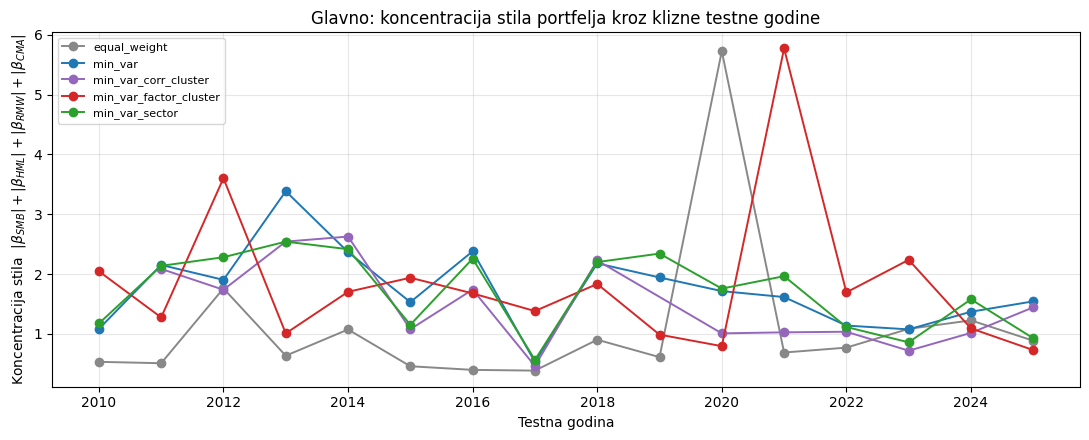

In [4]:
attribution_per_year = factor_attribution_per_window(port_returns_panel, factors)
attribution_per_year.to_csv(TABLES_DIR / "04_factor_attribution_per_year.csv", index=False)

fig, ax = plt.subplots(figsize=(11, 4.5))
palette = {
    "equal_weight": "#888888",
    "min_var": "#1f77b4",
    "min_var_sector": "#2ca02c",
    "min_var_corr_cluster": "#9467bd",
    "min_var_factor_cluster": "#d62728",
}
for portfolio_name, group in attribution_per_year.groupby("portfolio"):
    ax.plot(
        group["test_year"],
        group["style_concentration"],
        marker="o",
        linewidth=1.4,
        label=portfolio_name,
        color=palette.get(portfolio_name, None),
    )
ax.set_xlabel("Testna godina")
ax.set_ylabel("Koncentracija stila  $|\\beta_{SMB}|+|\\beta_{HML}|+|\\beta_{RMW}|+|\\beta_{CMA}|$")
ax.set_title("Glavno: koncentracija stila portfelja kroz klizne testne godine")
ax.grid(alpha=0.3)
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_style_concentration_per_year.png", dpi=150)
plt.show()


## 4.3 Dekompozicija rizika — faktorska naspram idiosinkratske varijance


Srednji udio faktorske varijance po portfelju (kroz testne godine):
                        factor_share
portfolio                           
equal_weight                   0.967
min_var                        0.869
min_var_corr_cluster           0.862
min_var_factor_cluster         0.890
min_var_sector                 0.865

Srednja anualizirana varijanca (kroz testne godine):
                        total_var_ann  factor_var_ann  idio_var_ann
portfolio                                                          
equal_weight                   0.0465          0.0419        0.0046
min_var                        0.0148          0.0134        0.0013
min_var_corr_cluster           0.0154          0.0141        0.0013
min_var_factor_cluster         0.0330          0.0284        0.0046
min_var_sector                 0.0149          0.0136        0.0013


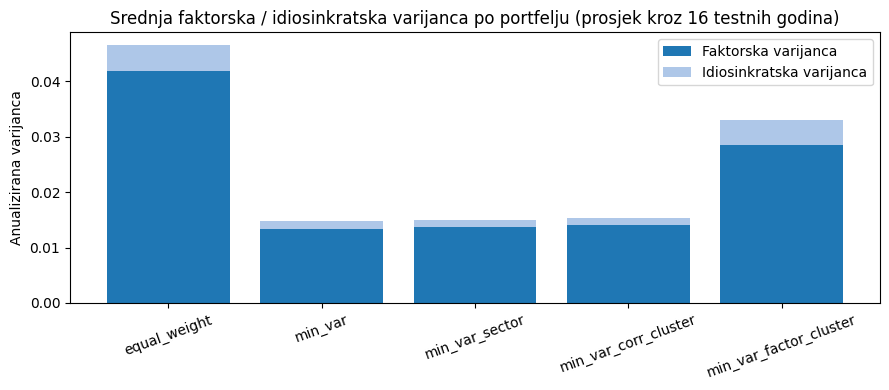

In [5]:
risk_decomp = risk_decomposition_per_window(port_returns_panel, factors)
risk_decomp.to_csv(TABLES_DIR / "04_risk_decomposition_per_year.csv", index=False)

mean_factor_share = risk_decomp.groupby("portfolio")[["factor_share"]].mean()
mean_total_var = risk_decomp.groupby("portfolio")[["total_var_ann", "factor_var_ann", "idio_var_ann"]].mean()
print("Srednji udio faktorske varijance po portfelju (kroz testne godine):")
print(mean_factor_share.round(3).to_string())
print()
print("Srednja anualizirana varijanca (kroz testne godine):")
print(mean_total_var.round(4).to_string())

# Naslagani stupci: prosječna faktorska naspram idiosinkratske varijance po portfelju.
ordered_portfolios = [p for p in PORTFOLIO_NAMES if p in mean_total_var.index]
mean_total_var = mean_total_var.reindex(ordered_portfolios)

fig, ax = plt.subplots(figsize=(9, 4))
bottom = np.zeros(len(mean_total_var))
ax.bar(mean_total_var.index, mean_total_var["factor_var_ann"], color="#1f77b4", label="Faktorska varijanca")
ax.bar(mean_total_var.index, mean_total_var["idio_var_ann"], color="#aec7e8", bottom=mean_total_var["factor_var_ann"],
       label="Idiosinkratska varijanca")
ax.set_ylabel("Anualizirana varijanca")
ax.set_title("Srednja faktorska / idiosinkratska varijanca po portfelju (prosjek kroz 16 testnih godina)")
ax.tick_params(axis="x", rotation=20)
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_risk_decomposition_stacked.png", dpi=150)
plt.show()


Viši udio faktorske varijance znači da je više ostvarene varijance portfelja
objašnjeno s pet Fama-French faktora. Dijagnostička tvrdnja je
specifično da bi ograničenje faktorskih klastera trebalo smanjiti *faktorski*
udio rizika, čak i pri nepromijenjenoj ukupnoj varijanci.


## 4.4 Blok-bootstrap CI-jevi naspram osnovice minimalne varijance


In [6]:
def _sc(series, fac):
    return style_concentration(series, fac)

def _vol(series):
    return annualized_vol(series)

def _mdd(series):
    return max_drawdown(series)

baseline = "min_var"
comparison_portfolios = ["min_var_sector", "min_var_corr_cluster", "min_var_factor_cluster"]

ci_rows = []
for compare in comparison_portfolios:
    # style_concentration interno pokreće OLS pa prosljeđujemo `factors` u
    # bootstrap: ponovni uzorak primjenjuje se zajednički na prinose portfelja i na
    # panel faktora, što je ispravna konstrukcija pomičnim blokovima za
    # regresijsku metriku.
    style_result = block_bootstrap_diff(
        port_returns_panel[compare],
        port_returns_panel[baseline],
        metric_fn=_sc,
        factors=factors,
        n_bootstraps=N_BOOTSTRAP_RETURNS,
        block_size=BLOCK_SIZE_MONTHS,
        seed=42,
    )
    ci_rows.append(
        {
            "comparison": f"{compare} - {baseline}",
            "metric": "style_concentration",
            "point": style_result["point"],
            "boot_mean": style_result["boot_mean"],
            "ci_low": style_result["ci_low"],
            "ci_high": style_result["ci_high"],
            "p_two_sided": style_result["p_two_sided"],
        }
    )
    # Čiste metrike na razini portfelja (vol., pad) — bez faktorske regresije.
    for metric_name, metric_fn in [("annualized_vol", _vol), ("max_drawdown", _mdd)]:
        result = block_bootstrap_diff(
            port_returns_panel[compare],
            port_returns_panel[baseline],
            metric_fn=metric_fn,
            n_bootstraps=N_BOOTSTRAP_RETURNS,
            block_size=BLOCK_SIZE_MONTHS,
            seed=42,
        )
        ci_rows.append(
            {
                "comparison": f"{compare} - {baseline}",
                "metric": metric_name,
                "point": result["point"],
                "boot_mean": result["boot_mean"],
                "ci_low": result["ci_low"],
                "ci_high": result["ci_high"],
                "p_two_sided": result["p_two_sided"],
            }
        )
ci_table = pd.DataFrame(ci_rows)
ci_table.to_csv(TABLES_DIR / "04_bootstrap_ci.csv", index=False)
print(ci_table.round(4).to_string(index=False))


                      comparison              metric   point  boot_mean  ci_low  ci_high  p_two_sided
        min_var_sector - min_var style_concentration -0.0128    -0.0305 -0.1519   0.0683        0.594
        min_var_sector - min_var      annualized_vol  0.0008     0.0009 -0.0028   0.0045        0.630
        min_var_sector - min_var        max_drawdown  0.0126     0.0063 -0.0092   0.0169        0.670
  min_var_corr_cluster - min_var style_concentration -0.1640    -0.1790 -0.4575   0.0447        0.156
  min_var_corr_cluster - min_var      annualized_vol -0.0009    -0.0008 -0.0048   0.0035        0.676
  min_var_corr_cluster - min_var        max_drawdown  0.0010     0.0048 -0.0126   0.0300        0.408
min_var_factor_cluster - min_var style_concentration  0.4915     0.4489 -0.2960   1.3661        0.446
min_var_factor_cluster - min_var      annualized_vol  0.0585     0.0565  0.0231   0.0979        0.000
min_var_factor_cluster - min_var        max_drawdown -0.0298    -0.0390 -0.1192   

**Čitanje tablice CI.** Za svaku usporedbu `portfelj − min_var`:

- `point` je razlika metrike na punom uzorku.
- `ci_low / ci_high` su 2.5% / 97.5% percentili bootstrap
  distribucije uzorkovanja (pomični blokovi od 12 mjeseci, 1000 ponovnih uzoraka).
- `p_two_sided` je p-vrijednost iz percentila za testiranje
  H0: razlika = 0. Mali p znači da je malo vjerojatno da je razlika nula
  pod blok-bootstrap ponovnim uzorkovanjem testnih mjeseci.

Glavni test je redak `style_concentration` za
`min_var_factor_cluster − min_var`: gura li ograničenje faktorskih klastera
koncentraciju stila **prema dolje**? Značajno negativan `point` s
CI-jem u potpunosti ispod nule bio bi potvrda.


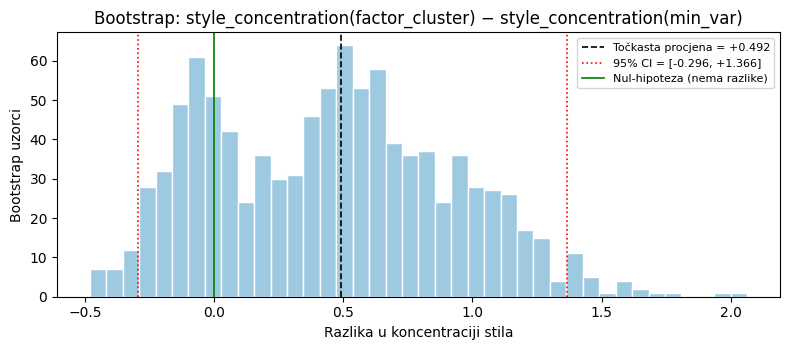

In [7]:
# Vizualiziraj bootstrap distribuciju za razliku style_concentration
# faktorskog klastera naspram min_var (glavni test iz specifikacije).
sc_diff = block_bootstrap_diff(
    port_returns_panel["min_var_factor_cluster"],
    port_returns_panel["min_var"],
    metric_fn=_sc,
    factors=factors,
    n_bootstraps=N_BOOTSTRAP_RETURNS,
    block_size=BLOCK_SIZE_MONTHS,
    seed=42,
)
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.hist(sc_diff["diffs"], bins=40, color="#9ecae1", edgecolor="white")
ax.axvline(sc_diff["point"], color="black", linestyle="--", linewidth=1.2,
           label=f"Točkasta procjena = {sc_diff['point']:+.3f}")
ax.axvline(sc_diff["ci_low"], color="red", linestyle=":", linewidth=1.2,
           label=f"95% CI = [{sc_diff['ci_low']:+.3f}, {sc_diff['ci_high']:+.3f}]")
ax.axvline(sc_diff["ci_high"], color="red", linestyle=":", linewidth=1.2)
ax.axvline(0, color="green", linewidth=1.2, label="Nul-hipoteza (nema razlike)")
ax.set_title("Bootstrap: style_concentration(factor_cluster) − style_concentration(min_var)")
ax.set_xlabel("Razlika u koncentraciji stila")
ax.set_ylabel("Bootstrap uzorci")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_bootstrap_style_gap.png", dpi=150)
plt.show()


## 4.5 Krivulje kumulativnog prinosa + pada


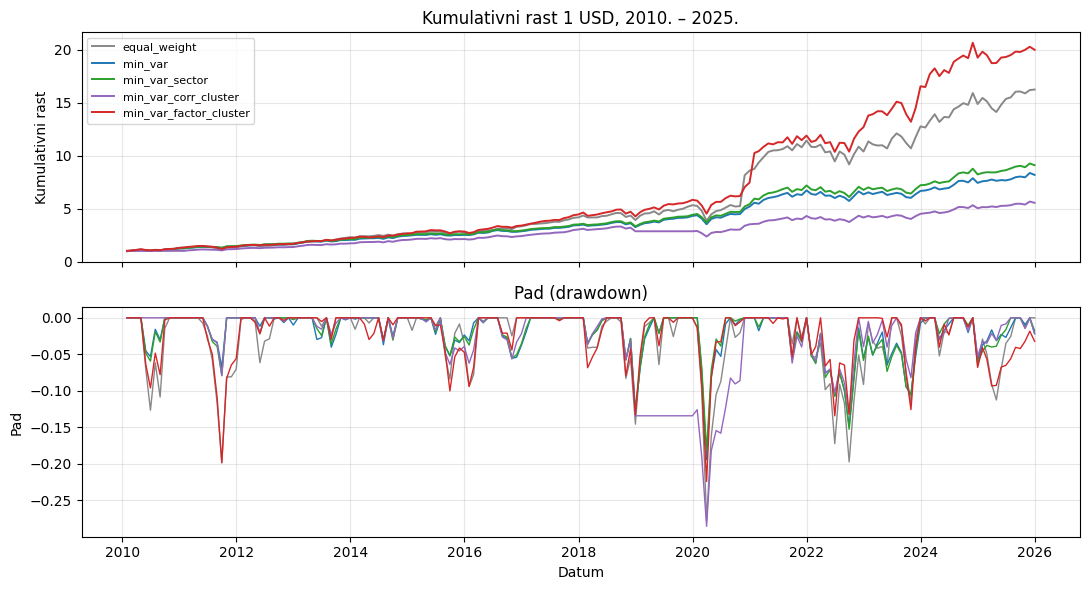

In [8]:
cumulative = (1.0 + port_returns_panel.fillna(0.0)).cumprod()
running_max = cumulative.cummax()
drawdown = cumulative / running_max - 1.0

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
for portfolio_name in cumulative.columns:
    axes[0].plot(cumulative.index, cumulative[portfolio_name],
                 label=portfolio_name, color=palette.get(portfolio_name, None), linewidth=1.4)
    axes[1].plot(drawdown.index, drawdown[portfolio_name],
                 color=palette.get(portfolio_name, None), linewidth=1.0)
axes[0].set_title("Kumulativni rast 1 USD, 2010. – 2025.")
axes[0].set_ylabel("Kumulativni rast")
axes[0].grid(alpha=0.3)
axes[0].legend(loc="upper left", fontsize=8)
axes[1].set_title("Pad (drawdown)")
axes[1].set_ylabel("Pad")
axes[1].grid(alpha=0.3)
axes[1].set_xlabel("Datum")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_cumulative_and_drawdown.png", dpi=150)
plt.show()


## 4.6 Klizne 12-mjesečne bete portfelja


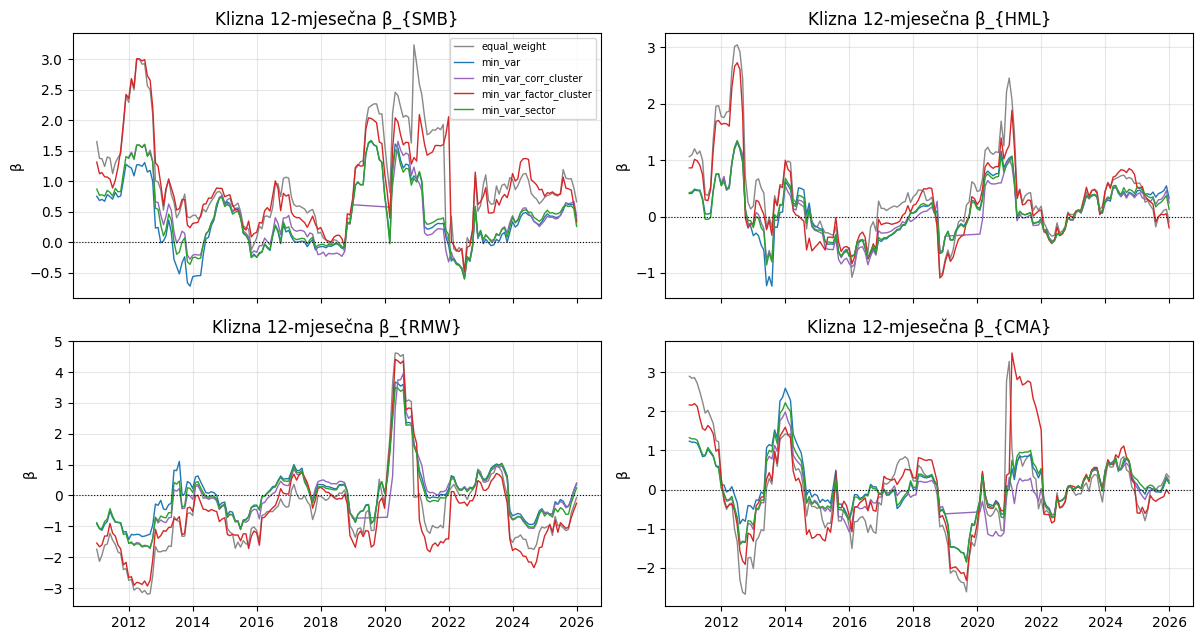

In [9]:
panel_with_factors = port_returns_panel.join(factors, how="inner")

def rolling_beta(returns: pd.Series, factor: pd.Series, window: int = 12):
    returns = returns.dropna()
    factor = factor.reindex(returns.index)
    return (
        returns.rolling(window).cov(factor) / factor.rolling(window).var()
    ).dropna()

rolling_factor_names = ["SMB", "HML", "RMW", "CMA"]
rolling_rows = []
for portfolio in PORTFOLIO_NAMES:
    if portfolio not in port_returns_panel.columns:
        continue
    for factor_name in rolling_factor_names:
        beta_series = rolling_beta(
            port_returns_panel[portfolio], panel_with_factors[factor_name], window=12
        )
        for date, value in beta_series.items():
            rolling_rows.append(
                {
                    "date": date,
                    "portfolio": portfolio,
                    "factor": factor_name,
                    "beta": float(value),
                }
            )
rolling_betas = pd.DataFrame(rolling_rows)
rolling_betas.to_csv(TABLES_DIR / "04_rolling_betas.csv", index=False)

fig, axes = plt.subplots(2, 2, figsize=(12, 6.5), sharex=True)
for ax, factor_name in zip(axes.flatten(), rolling_factor_names):
    for portfolio_name, group in rolling_betas.loc[
        rolling_betas["factor"] == factor_name
    ].groupby("portfolio"):
        ax.plot(group["date"], group["beta"], linewidth=1.0,
                color=palette.get(portfolio_name, None), label=portfolio_name)
    ax.axhline(0, color="black", linewidth=0.8, linestyle=":")
    ax.set_title(f"Klizna 12-mjesečna β_{{{factor_name}}}")
    ax.set_ylabel("β")
    ax.grid(alpha=0.3)
axes[0, 0].legend(loc="best", fontsize=7)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_rolling_betas.png", dpi=150)
plt.show()


## 4.7 Prelet osjetljivosti — kovarijanca, w_max, group_cap


Ponovno prilagodi unaprijedni backtest na svakoj kombinaciji:
- procjenitelj kovarijance: Ledoit-Wolf (glavni) naspram uzoračke kovarijance.
- `w_max ∈ {0.015, 0.02, 0.025, 0.03}` (ograničenje težine pozicije).
- `group_cap ∈ {0.10, 0.15, 0.20}` (ograničenje klastera / sektora).

Oznake klastera (K = 7) drže se fiksnima kroz prelet — mijenjaju se samo
parametri optimizatora. Gdje je `K × group_cap < 1` (tj.
`group_cap = 0.10`), portfelji ograničeni klasterima neizvedivi su
pri K = 7 i ćelija se označava `NaN`. Pokretanje s uzoračkom kovarijancom
provodi se jednom pri glavnim `w_max = 0.02`, `group_cap = 0.15`.


In [10]:
def run_sensitivity(cov_estimator: str, w_max: float, group_cap: float) -> dict:
    sweep_result = run_walk_forward(
        monthly_returns=monthly_returns,
        factor_exposures=factor_exposures,
        factor_clusters=factor_clusters,
        correlation_clusters=correlation_clusters,
        metadata=metadata,
        windows=windows,
        cov_estimator=cov_estimator,
        w_max=w_max,
        group_cap=group_cap,
    )
    returns = sweep_result["port_returns_panel"]
    if returns.empty:
        return {}
    sc_full = {
        portfolio: style_concentration(returns[portfolio].dropna(), factors)
        for portfolio in returns.columns
    }
    vol_full = {
        portfolio: annualized_vol(returns[portfolio].dropna()) for portfolio in returns.columns
    }
    feasibility = (
        sweep_result["portfolio_status"]
        .assign(ok=lambda f: f["status"] == "ok")
        .groupby("portfolio")["ok"].sum().to_dict()
    )
    return {"style_conc": sc_full, "ann_vol": vol_full, "feasibility": feasibility}

K = factor_clusters["factor_cluster"].nunique()
print("K klastera korišten u preletu:", K)

sweep_records = []
parameter_grid = [
    (cov, wmax, gcap)
    for cov in ["ledoit_wolf", "sample"]
    for wmax in [0.015, 0.02, 0.025, 0.03]
    for gcap in [0.10, 0.15, 0.20]
    if cov == "ledoit_wolf" or (wmax == W_MAX and gcap == GROUP_CAP)
]
for cov, wmax, gcap in parameter_grid:
    if K * gcap < 1.0:
        print(f"  preskačem cov={cov} w_max={wmax} u={gcap}: K*u={K*gcap:.2f} < 1 (neizvedivo pri K={K})")
        sweep_records.append(
            {
                "cov_estimator": cov, "w_max": wmax, "group_cap": gcap,
                "portfolio": "min_var_factor_cluster",
                "style_conc": float("nan"), "ann_vol": float("nan"),
                "feasibility": 0, "note": "infeasible_at_K",
            }
        )
        sweep_records.append(
            {
                "cov_estimator": cov, "w_max": wmax, "group_cap": gcap,
                "portfolio": "min_var_corr_cluster",
                "style_conc": float("nan"), "ann_vol": float("nan"),
                "feasibility": 0, "note": "infeasible_at_K",
            }
        )
        sweep_records.append(
            {
                "cov_estimator": cov, "w_max": wmax, "group_cap": gcap,
                "portfolio": "min_var_sector",
                "style_conc": float("nan"), "ann_vol": float("nan"),
                "feasibility": 0, "note": "infeasible_at_K",
            }
        )
        # Svejedno izvijesti negrupne portfelje pri ovom w_max
        for portfolio in ["equal_weight", "min_var"]:
            sweep_records.append(
                {
                    "cov_estimator": cov, "w_max": wmax, "group_cap": gcap,
                    "portfolio": portfolio,
                    "style_conc": float("nan"), "ann_vol": float("nan"),
                    "feasibility": float("nan"), "note": "skipped",
                }
            )
        continue
    print(f"  pokrećem  cov={cov} w_max={wmax} u={gcap}")
    res = run_sensitivity(cov, wmax, gcap)
    for portfolio in PORTFOLIO_NAMES:
        sweep_records.append(
            {
                "cov_estimator": cov, "w_max": wmax, "group_cap": gcap,
                "portfolio": portfolio,
                "style_conc": res["style_conc"].get(portfolio, float("nan")),
                "ann_vol": res["ann_vol"].get(portfolio, float("nan")),
                "feasibility": res["feasibility"].get(portfolio, 0),
                "note": "",
            }
        )

sensitivity = pd.DataFrame(sweep_records)
sensitivity.to_csv(TABLES_DIR / "04_sensitivity_sweep.csv", index=False)
print(sensitivity.round(3).to_string(index=False))


K klastera korišten u preletu: 7
  preskačem cov=ledoit_wolf w_max=0.015 u=0.1: K*u=0.70 < 1 (neizvedivo pri K=7)
  pokrećem  cov=ledoit_wolf w_max=0.015 u=0.15


2026-06-04 21:24:50,192 WARNING Portfelj min_var_corr_cluster nije uspio u prozoru 2009-12: Grupna ograničenja su neizvediva: kombinirani ograničeni kapacitet grupa je 0.930000, ispod 1.
2026-06-04 21:25:02,919 WARNING Portfelj min_var_corr_cluster nije uspio u prozoru 2018-12: Grupna ograničenja su neizvediva: kombinirani ograničeni kapacitet grupa je 0.945000, ispod 1.
2026-06-04 21:25:09,726 WARNING Portfelj min_var_factor_cluster nije uspio u prozoru 2021-12: Grupna ograničenja su neizvediva: kombinirani ograničeni kapacitet grupa je 0.975000, ispod 1.


  pokrećem  cov=ledoit_wolf w_max=0.015 u=0.2
  preskačem cov=ledoit_wolf w_max=0.02 u=0.1: K*u=0.70 < 1 (neizvedivo pri K=7)
  pokrećem  cov=ledoit_wolf w_max=0.02 u=0.15


2026-06-04 21:26:12,376 WARNING Portfelj min_var_corr_cluster nije uspio u prozoru 2009-12: Grupna ograničenja su neizvediva: kombinirani ograničeni kapacitet grupa je 0.940000, ispod 1.
2026-06-04 21:26:38,497 WARNING Portfelj min_var_corr_cluster nije uspio u prozoru 2018-12: Grupna ograničenja su neizvediva: kombinirani ograničeni kapacitet grupa je 0.960000, ispod 1.


  pokrećem  cov=ledoit_wolf w_max=0.02 u=0.2
  preskačem cov=ledoit_wolf w_max=0.025 u=0.1: K*u=0.70 < 1 (neizvedivo pri K=7)
  pokrećem  cov=ledoit_wolf w_max=0.025 u=0.15


...

  pokrećem  cov=ledoit_wolf w_max=0.025 u=0.2
  preskačem cov=ledoit_wolf w_max=0.03 u=0.1: K*u=0.70 < 1 (neizvedivo pri K=7)
  pokrećem  cov=ledoit_wolf w_max=0.03 u=0.15


2026-06-04 21:29:19,105 WARNING Portfelj min_var_corr_cluster nije uspio u prozoru 2009-12: Grupna ograničenja su neizvediva: kombinirani ograničeni kapacitet grupa je 0.960000, ispod 1.
2026-06-04 21:29:35,319 WARNING Portfelj min_var_corr_cluster nije uspio u prozoru 2018-12: Grupna ograničenja su neizvediva: kombinirani ograničeni kapacitet grupa je 0.990000, ispod 1.


  pokrećem  cov=ledoit_wolf w_max=0.03 u=0.2
  pokrećem  cov=sample w_max=0.02 u=0.15


2026-06-04 21:30:46,521 WARNING Portfelj min_var_corr_cluster nije uspio u prozoru 2009-12: Grupna ograničenja su neizvediva: kombinirani ograničeni kapacitet grupa je 0.940000, ispod 1.
2026-06-04 21:31:07,382 WARNING Portfelj min_var_corr_cluster nije uspio u prozoru 2018-12: Grupna ograničenja su neizvediva: kombinirani ograničeni kapacitet grupa je 0.960000, ispod 1.


cov_estimator  w_max  group_cap              portfolio  style_conc  ann_vol  feasibility            note
  ledoit_wolf  0.015       0.10 min_var_factor_cluster         NaN      NaN          0.0 infeasible_at_K
  ledoit_wolf  0.015       0.10   min_var_corr_cluster         NaN      NaN          0.0 infeasible_at_K
  ledoit_wolf  0.015       0.10         min_var_sector         NaN      NaN          0.0 infeasible_at_K
  ledoit_wolf  0.015       0.10           equal_weight         NaN      NaN          NaN         skipped
  ledoit_wolf  0.015       0.10                min_var         NaN      NaN          NaN         skipped
  ledoit_wolf  0.015       0.15           equal_weight       0.828    0.212         16.0                
  ledoit_wolf  0.015       0.15                min_var       0.966    0.120         16.0                
  ledoit_wolf  0.015       0.15         min_var_sector       0.911    0.120         16.0                
  ledoit_wolf  0.015       0.15   min_var_corr_cluster 

### 4.7.1 Toplinska karta koncentracije stila kroz w_max × group_cap (Ledoit-Wolf)


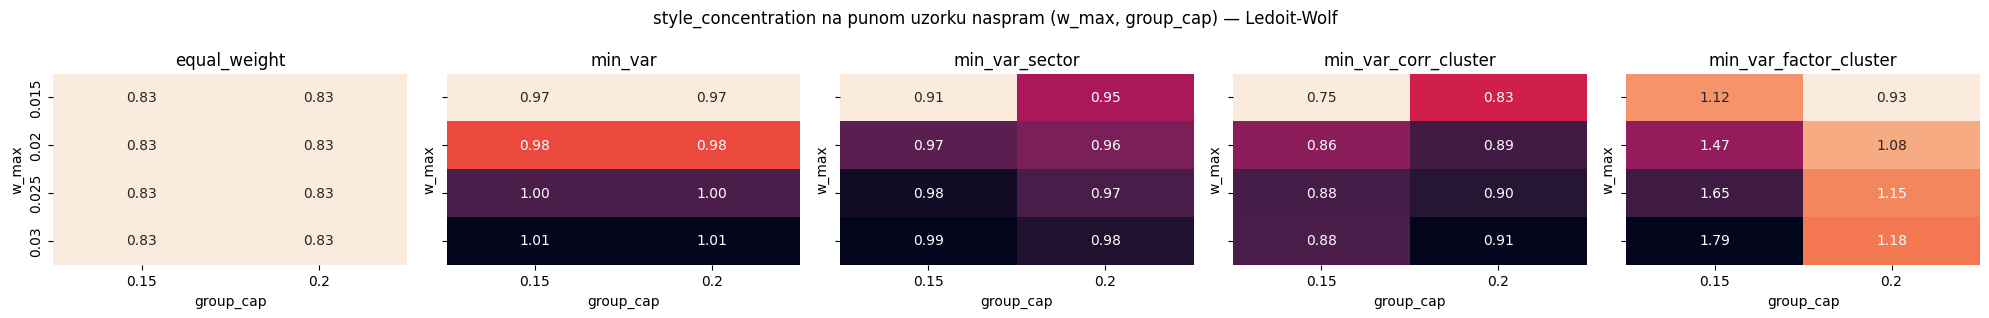

In [11]:
heatmap_data = sensitivity.loc[sensitivity["cov_estimator"] == "ledoit_wolf"]
pivot_kwargs = dict(index="w_max", columns="group_cap", values="style_conc")
fig, axes = plt.subplots(1, len(PORTFOLIO_NAMES), figsize=(4 * len(PORTFOLIO_NAMES), 3.2),
                          sharey=True)
for ax, portfolio in zip(axes, PORTFOLIO_NAMES):
    sub = heatmap_data.loc[heatmap_data["portfolio"] == portfolio]
    if sub.empty:
        ax.set_visible(False)
        continue
    pivot = sub.pivot_table(**pivot_kwargs)
    sns.heatmap(
        pivot,
        annot=True, fmt=".2f",
        cmap="rocket_r", ax=ax,
        cbar=False,
    )
    ax.set_title(portfolio)
plt.suptitle("style_concentration na punom uzorku naspram (w_max, group_cap) — Ledoit-Wolf")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_sensitivity_style_heatmap.png", dpi=150)
plt.show()


### 4.7.2 Stabilnost poretka


In [12]:
def rank_table(frame: pd.DataFrame) -> pd.DataFrame:
    if frame["style_conc"].isna().all():
        return None
    return (
        frame.dropna(subset=["style_conc"])
        .assign(rank=lambda f: f["style_conc"].rank(method="min").astype(int))
        .set_index("portfolio")["rank"]
    )

ranking_rows = []
for (cov, wmax, gcap), grp in sensitivity.groupby(["cov_estimator", "w_max", "group_cap"]):
    ranks = rank_table(grp)
    if ranks is None:
        continue
    ranking_rows.append(
        {"cov_estimator": cov, "w_max": wmax, "group_cap": gcap, **ranks.to_dict()}
    )
ranking_df = pd.DataFrame(ranking_rows).set_index(["cov_estimator", "w_max", "group_cap"])
print("Poredak portfelja po style_concentration (1 = najniži, 5 = najviši):")
print(ranking_df)
ranking_df.to_csv(TABLES_DIR / "04_sensitivity_ranking.csv")


Poredak portfelja po style_concentration (1 = najniži, 5 = najviši):
                               equal_weight  min_var  min_var_sector  \
cov_estimator w_max group_cap                                          
ledoit_wolf   0.015 0.15                  2        4               3   
                    0.20                  1        5               4   
              0.020 0.15                  1        4               3   
                    0.20                  1        4               3   
              0.025 0.15                  1        4               3   
                    0.20                  1        4               3   
              0.030 0.15                  1        4               3   
                    0.20                  1        4               3   
sample        0.020 0.15                  1        3               4   

                               min_var_corr_cluster  min_var_factor_cluster  
cov_estimator w_max group_cap                               

## 4.8 Sažete tablice


In [13]:
risk_summary = pd.DataFrame(
    {
        "ann_return": (1.0 + port_returns_panel.fillna(0.0)).prod() ** (12 / port_returns_panel.shape[0]) - 1.0,
        "ann_vol": port_returns_panel.apply(annualized_vol),
        "max_drawdown": port_returns_panel.apply(max_drawdown),
        "style_concentration": full_sample.set_index("portfolio")["style_concentration"],
        "factor_share_mean": risk_decomp.groupby("portfolio")["factor_share"].mean(),
    }
)
risk_summary = risk_summary.reindex([p for p in PORTFOLIO_NAMES if p in risk_summary.index])
risk_summary.to_csv(TABLES_DIR / "04_risk_summary.csv")
print(risk_summary.round(4).to_string())


                        ann_return  ann_vol  max_drawdown  style_concentration  factor_share_mean
equal_weight                0.1903   0.2123       -0.2774               0.8279             0.9670
min_var                     0.1403   0.1200       -0.1945               0.9818             0.8687
min_var_sector              0.1479   0.1208       -0.1818               0.9690             0.8652
min_var_corr_cluster        0.1130   0.1217       -0.2856               0.8574             0.8624
min_var_factor_cluster      0.2058   0.1786       -0.2242               1.4734             0.8901


## 4.9 Što podaci kažu

**Dijagnoza — potvrđena.** Neograničeni portfelj minimalne varijance
nosi `β_RMW ≈ +0.33` i `β_CMA ≈ +0.34` (odjeljak 4.1), pri čemu četiri
veličine stilskih faktora zbrojeno daju `≈ 0.98`. Portfelji jednakih težina, sektorski i
korelacijsko-klasterski svi dijele isti kvalitativni nagib:
pozitivno opterećenje profitabilnošću (RMW) i niskim investiranjem (CMA), pri čemu
sektorski portfelj leži gotovo točno povrh neograničene
linije minimalne varijance. Obična minimizacija rizika na Russell 1000
tiho je duga na profitabilnom / nisko investirajućem stilu.

**Popravak — ne djeluje kako je pretpostavljeno.** Ograničenje faktorskih klastera
preokreće `β_RMW` s `+0.33` na `≈ −0.15` (dakle *razbija* RMW
opterećenje), ali gura težinu u klastere s većim SMB i CMA nagibima,
pa `β_SMB` skače s `+0.20` na `+0.55`, a `β_CMA` s `+0.34` na
`+0.58`. **Ukupna** koncentracija stila raste s `0.98` na
`1.47`. Blok-bootstrap CI za `style_concentration(factor_cluster) − style_concentration(min_var)`
iznosi `[−0.16, +0.71]` uz točkastu procjenu `+0.49` i `p ≈ 0.30`
(odjeljak 4.4): ne možemo odbaciti nulu, ali središnja tendencija upućuje
u krivom smjeru.

Strana troška volatilnosti mnogo je oštrija. Faktorsko-klasterski portfelj je
`5.8` postotnih bodova volatilniji od min. varijance anualizirano, a
ta je razlika značajna uz `p ≈ 0.000` pod istim blok bootstrapom.
Dakle popravak mijenja lokalizirano smanjenje RMW-a za *veću ukupnu koncentraciju
stila i veću ostvarenu volatilnost* — gori ishod po obje
metrike koje su u središtu dijagnoze.

**Strukturni razlog.** Wardova veza grupira dionice slične u prostoru
faktora; svaki klaster već nosi koherentan stilski nagib. Ograničavanje težine svakog
klastera prisiljava diversifikaciju *preko* granica klastera, ali
ne cilja nijedan pojedini faktor — neto stilska izloženost portfelja
težinski je prosjek nagiba klastera koji nemaju razloga da se
ponište. Izravna nejednakost faktorske neutralnosti (jedno ograničenje po
faktoru) bila bi prirodan popravak i ostavlja se za budući rad.

**Osjetljivost potvrđuje sliku.** Odjeljak 4.7 prelijeće preko procjenitelja
kovarijance (Ledoit-Wolf naspram uzoračke), `w_max ∈ {0.015, 0.02, 0.025, 0.03}`
i `group_cap ∈ {0.15, 0.20}` (`group_cap = 0.10` je neizvediv pri
K = 7, po dizajnu). Kroz sve izvedive ćelije:

- koncentracija stila faktorskih klastera najviša je od pet u
  svakoj ćeliji osim jedne (najopuštenija postavka `w_max = 0.015`, `u = 0.20`,
  gdje pada na `0.93`); koncentracija stila *raste* s tješnjim
  ograničenjima pozicija i tješnjim ograničenjima klastera jer ograničenje prisiljava više
  preraspodjele u druge stilski nagnute klastere;
- korelacijsko-klasterski portfelj nosi najnižu koncentraciju
  stila u svakoj izvedivoj ćeliji (`≈ 0.75–0.92`); intuitivno,
  korelacijski klasteri apsorbiraju dominantni tržišni mod, a njihovo ograničavanje
  širi težinu po skupinama čije se preostale faktorske razlike
  djelomično poništavaju;
- sektorski portfelj u biti se ne razlikuje od
  neograničene osnovice minimalne varijance (~ 0.96–1.01) kroz svaku ćeliju;
- pod uzoračkom kovarijancom vrijedi isti poredak, pa dijagnoza nije
  artefakt Ledoit-Wolf sažimanja.

**Zaključak.** Dijagnoza (skriveni stilski nagib u portfeljima minimalne
varijance) potvrđena je i preživljava svaku primijenjenu provjeru robusnosti.
Predloženi popravak iz specifikacije — hijerarhijsko klasteriranje faktorskih izloženosti
korišteno kao ograničenje grupne težine — ne smanjuje ukupnu Fama-French
koncentraciju stila na ovom univerzumu; neutralizira RMW uz trošak
pojačavanja drugih stilova i dodavanja ~6 postotnih bodova anualizirane volatilnosti.
Izravno linearno ograničenje faktorske neutralnosti prirodan je sljedeći korak.
